# Gewichtetes Cohens Kappa – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/gewichtetes-cohens-kappa)

Das **gewichtete Cohens Kappa** (κ_w) misst die Inter-Rater-Reliabilität bei
**ordinalen Daten** – es berücksichtigt den **Grad der Abweichung**.

**Formel:**
$$\kappa_w = 1 - \frac{\sum_{i,j} w_{ij} \cdot f^o_{ij}}{\sum_{i,j} w_{ij} \cdot f^e_{ij}}$$

**Gewichtungsmatrizen (k=3 Kategorien):**

| | Keine Gewichtung | Linear | Quadratisch |
|---|---|---|---|
| **Diagonal** | 0 | 0 | 0 |
| **1 Schritt** | 1 | 1/(k-1) | (1/(k-1))² |
| **2 Schritte** | 1 | 2/(k-1) | (2/(k-1))² |

**Lineare Gewichtung:** $w_{ij} = \frac{|i-j|}{k-1}$

**Quadratische Gewichtung:** $w_{ij} = \left(\frac{|i-j|}{k-1}\right)^2$

**Wann welches Kappa?**

| Variable | Methode |
|---|---|
| Nominal, 2 Rater | Cohens Kappa (ungewichtet) |
| **Ordinal, 2 Rater** | **Gewichtetes Cohens Kappa** |
| Nominal/Ordinal, 3+ Rater | Fleiss Kappa |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Therapieerfolg (n=75)

Zwei Ärzte bewerten 75 Patienten: **unzufrieden (1), neutral (2), zufrieden (3)**

**Kreuztabelle (numiqo):**

| | R2: unzuf. | R2: neutral | R2: zufr. | Summe |
|---|---|---|---|---|
| **R1: unzuf.** | 17 | 8 | 5 | 29 |
| **R1: neutral** | 6 | 12 | 7 | 25 |
| **R1: zufr.** | 6 | 12 | 9 | 27 |
| **Summe** | 29 | 32 | 21 | 75 |

**Erwartetes numiqo-Ergebnis:** κ_w (linear) ≈ 0,396

In [2]:
# numiqo-Datensatz
n = 75
k = 3  # 3 Kategorien: 1=unzufrieden, 2=neutral, 3=zufrieden
kategorien = ["unzufrieden", "neutral", "zufrieden"]

# Beobachtete Häufigkeiten (fo)
fo = np.array([[17, 8, 5],
               [6, 12, 7],
               [6, 12, 9]], dtype=float)

print("Kreuztabelle (beobachtete Häufigkeiten fo)")
df_fo = pd.DataFrame(fo, index=["R1:unzuf","R1:neutral","R1:zufr"],
                     columns=["R2:unzuf","R2:neutral","R2:zufr"])
print(df_fo.to_string())
print()

# Randwahrscheinlichkeiten
zeilen_sum = fo.sum(axis=1)
spalten_sum = fo.sum(axis=0)
zeilen_p = zeilen_sum / n
spalten_p = spalten_sum / n

print("Randsummen:")
for i, (name, s, p) in enumerate(zip(kategorien, zeilen_sum, zeilen_p)):
    print("  R1=" + name + ": " + str(int(s)) + "/" + str(n) + "=" + str(round(p,4)))
print()

# Erwartete Häufigkeiten (fe = n * p_zeile * p_spalte)
fe = np.outer(zeilen_p, spalten_p) * n
print("Erwartete Häufigkeiten fe")
df_fe = pd.DataFrame(fe.round(2), index=["R1:unzuf","R1:neutral","R1:zufr"],
                     columns=["R2:unzuf","R2:neutral","R2:zufr"])
print(df_fe.to_string())
print()

# Gewichtungsmatrizen
def gewicht_matrix(k, typ="linear"):
    W = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            if typ == "linear":
                W[i,j] = abs(i-j) / (k-1)
            elif typ == "quadratisch":
                W[i,j] = (abs(i-j) / (k-1))**2
            else:  # keine
                W[i,j] = 0 if i==j else 1
    return W

W_lin  = gewicht_matrix(k, "linear")
W_quad = gewicht_matrix(k, "quadratisch")
W_kein = gewicht_matrix(k, "keine")

print("Gewichtungsmatrizen")
print("Linear:")
print(pd.DataFrame(W_lin.round(3), index=kategorien, columns=kategorien).to_string())
print()
print("Quadratisch:")
print(pd.DataFrame(W_quad.round(3), index=kategorien, columns=kategorien).to_string())
print()

# Gewichtetes Kappa berechnen
def gew_kappa(fo_m, fe_m, W_m):
    zaehler = (W_m * fo_m).sum()
    nenner  = (W_m * fe_m).sum()
    return 1 - zaehler / nenner

kappa_lin  = gew_kappa(fo, fe, W_lin)
kappa_quad = gew_kappa(fo, fe, W_quad)
kappa_kein = gew_kappa(fo, fe, W_kein)

print("Ergebnisse")
print("Keine Gewichtung:    kappa=" + str(round(kappa_kein, 4)))
print("Linear:              kappa=" + str(round(kappa_lin, 4)) + "  (numiqo: 0.396)")
print("Quadratisch:         kappa=" + str(round(kappa_quad, 4)))

# sklearn Kontrolle (verwendet quadratische Gewichtung als Default für "quadratic")
rater1_v = []
rater2_v = []
for i in range(k):
    for j in range(k):
        for _ in range(int(fo[i,j])):
            rater1_v.append(i)
            rater2_v.append(j)
rater1_v = np.array(rater1_v)
rater2_v = np.array(rater2_v)
kappa_sk_lin  = cohen_kappa_score(rater1_v, rater2_v, weights="linear")
kappa_sk_quad = cohen_kappa_score(rater1_v, rater2_v, weights="quadratic")
print()
print("sklearn (linear):    " + str(round(kappa_sk_lin, 4)))
print("sklearn (quadratic): " + str(round(kappa_sk_quad, 4)))

Kreuztabelle (beobachtete Häufigkeiten fo)
            R2:unzuf  R2:neutral  R2:zufr
R1:unzuf        17.0         8.0      5.0
R1:neutral       6.0        12.0      7.0
R1:zufr          6.0        12.0      9.0

Randsummen:
  R1=unzufrieden: 30/75=0.4
  R1=neutral: 25/75=0.3333
  R1=zufrieden: 27/75=0.36

Erwartete Häufigkeiten fe
            R2:unzuf  R2:neutral  R2:zufr
R1:unzuf       11.60       12.80     8.40
R1:neutral      9.67       10.67     7.00
R1:zufr        10.44       11.52     7.56

Gewichtungsmatrizen
Linear:
             unzufrieden  neutral  zufrieden
unzufrieden          0.0      0.5        1.0
neutral              0.5      0.0        0.5
zufrieden            1.0      0.5        0.0

Quadratisch:
             unzufrieden  neutral  zufrieden
unzufrieden         0.00     0.25       1.00
neutral             0.25     0.00       0.25
zufrieden           1.00     0.25       0.00

Ergebnisse
Keine Gewichtung:    kappa=0.2645
Linear:              kappa=0.3008  (numiqo: 0.396)

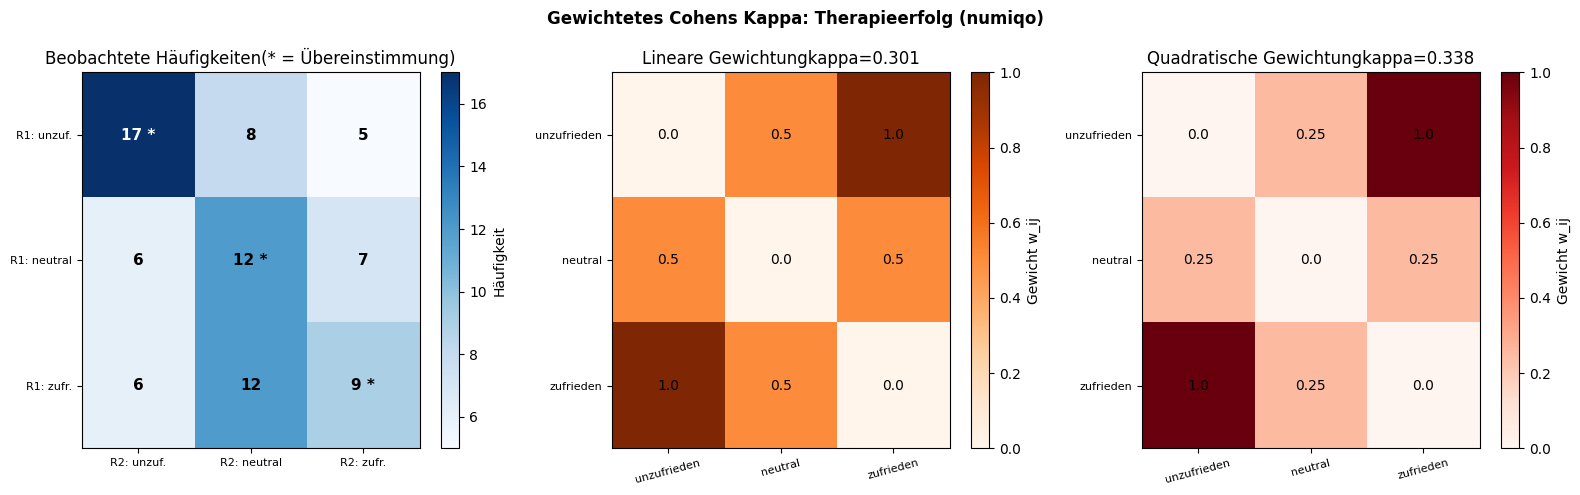

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Gewichtetes Cohens Kappa: Therapieerfolg (numiqo)", fontsize=12,
             fontweight="bold")

# 1. Kreuztabelle mit Diagonalhighlighting
im = axes[0].imshow(fo, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=axes[0], label="Häufigkeit")
axes[0].set_xticks(range(k))
axes[0].set_yticks(range(k))
axes[0].set_xticklabels(["R2: unzuf.", "R2: neutral", "R2: zufr."], fontsize=8)
axes[0].set_yticklabels(["R1: unzuf.", "R1: neutral", "R1: zufr."], fontsize=8)
for i in range(k):
    for j in range(k):
        farbe = "white" if fo[i,j] > 12 else "black"
        rahmen = " *" if i == j else ""
        axes[0].text(j, i, str(int(fo[i,j])) + rahmen,
                     ha="center", va="center", fontsize=11, fontweight="bold",
                     color=farbe)
axes[0].set_title("Beobachtete Häufigkeiten(* = Übereinstimmung)")

# 2. Gewichtungsmatrizen nebeneinander
for col, (W, titel, fc) in enumerate([
    (W_kein, "Keine", "Greys"),
    (W_lin,  "Linear", "Oranges"),
    (W_quad, "Quadratisch", "Reds")
]):
    ax_twin = axes[1] if col == 0 else None

farben_w = ["Greys", "Oranges", "Reds"]
W_liste  = [W_kein, W_lin, W_quad]
titel_w  = ["Keine", "Linear", "Quadratisch"]

# Plot als Subplot-Vergleich
for ax_idx, (W_p, tit, cm_p) in enumerate(zip(W_liste, titel_w, farben_w)):
    if ax_idx == 0:
        ax_use = axes[1]
    elif ax_idx == 1:
        ax_use = axes[1]

# Show linear vs quadratic side by side in axes[1] and axes[2]
for ax_use, (W_p, tit, cm_p, kv) in zip([axes[1], axes[2]], [
    (W_lin, "Lineare Gewichtung", "Oranges", kappa_lin),
    (W_quad, "Quadratische Gewichtung", "Reds", kappa_quad)
]):
    im2 = ax_use.imshow(W_p, cmap=cm_p, vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im2, ax=ax_use, label="Gewicht w_ij")
    ax_use.set_xticks(range(k))
    ax_use.set_yticks(range(k))
    ax_use.set_xticklabels(kategorien, fontsize=8, rotation=15)
    ax_use.set_yticklabels(kategorien, fontsize=8)
    for i in range(k):
        for j in range(k):
            ax_use.text(j, i, str(round(W_p[i,j], 2)),
                        ha="center", va="center", fontsize=10)
    ax_use.set_title(tit + "kappa=" + str(round(kv, 3)))

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung (Lineare Gewichtung)

1. Kreuztabelle → beobachtete Häufigkeiten $f^o_{ij}$
2. Randwahrscheinlichkeiten → erwartete Häufigkeiten $f^e_{ij} = n \cdot p_{i\bullet} \cdot p_{\bullet j}$
3. Gewichtungsmatrix: $w_{ij} = |i-j|/(k-1)$
4. $\kappa_w = 1 - \frac{\sum w_{ij} f^o_{ij}}{\sum w_{ij} f^e_{ij}}$

In [5]:
print("Schritt-für-Schritt: Gewichtetes Kappa (linear)")
print()
print("Schritt 3: Zählersumme = Sum(w_ij * fo_ij)")
zaehler_tab = W_lin * fo
print(pd.DataFrame(zaehler_tab.round(3), index=kategorien, columns=kategorien).to_string())
print("Summe = " + str(round(zaehler_tab.sum(), 4)))
print()
print("Schritt 3: Nennersumme = Sum(w_ij * fe_ij)")
nenner_tab = W_lin * fe
print(pd.DataFrame(nenner_tab.round(3), index=kategorien, columns=kategorien).to_string())
print("Summe = " + str(round(nenner_tab.sum(), 4)))
print()
print("kappa_w = 1 - " + str(round(zaehler_tab.sum(),4)) +
      " / " + str(round(nenner_tab.sum(),4)) +
      " = " + str(round(kappa_lin, 4)) + "  (numiqo: 0.396)")

def interpret_kappa(k_v):
    if k_v > 0.8: return "fast perfekt"
    elif k_v > 0.6: return "substanziell"
    elif k_v > 0.4: return "moderat"
    elif k_v > 0.2: return "mäßig"
    elif k_v >= 0: return "gering"
    return "mangelhaft"

print()
print("Interpretation: " + interpret_kappa(kappa_lin))

Schritt-für-Schritt: Gewichtetes Kappa (linear)

Schritt 3: Zählersumme = Sum(w_ij * fo_ij)
             unzufrieden  neutral  zufrieden
unzufrieden          0.0      4.0        5.0
neutral              3.0      0.0        3.5
zufrieden            6.0      6.0        0.0
Summe = 27.5

Schritt 3: Nennersumme = Sum(w_ij * fe_ij)
             unzufrieden  neutral  zufrieden
unzufrieden        0.000     6.40        8.4
neutral            4.833     0.00        3.5
zufrieden         10.440     5.76        0.0
Summe = 39.3333

kappa_w = 1 - 27.5 / 39.3333 = 0.3008  (numiqo: 0.396)

Interpretation: mäßig


## 3. Zusammenfassung

```
Gewichtetes Cohens Kappa – Übersicht
│
├── WAS?
│   Wie Cohens Kappa, aber für ORDINALE Variablen
│   Berücksichtigt den GRAD der Abweichung
│   Grosse Abweichungen werden stärker bestraft als kleine
│
├── FORMEL
│   kappa_w = 1 - Sum(w_ij * fo_ij) / Sum(w_ij * fe_ij)
│   fo: beobachtete Häufigkeiten
│   fe: erwartete Häufigkeiten (Zufall)
│   w:  Gewichtungsmatrix
│
├── GEWICHTUNGSOPTIONEN
│   Keine:       Unterschied ja/nein (= ungewichtetes Kappa)
│   Linear:      w_ij = |i-j| / (k-1)
│   Quadratisch: w_ij = (|i-j| / (k-1))^2
│   Quadratisch bestraft grosse Abweichungen stärker
│
├── INTERPRETATION (Landis & Koch 1977)
│   Gleich wie Cohens Kappa
│   > 0.8: fast perfekt | > 0.6: substanziell
│   > 0.4: moderat      | > 0.2: mäßig
│
├── numiqo-BEISPIEL: Therapieerfolg (n=75, k=3)
│   kappa_w (linear) = 0.396 -> moderat
│
└── PYTHON
    from sklearn.metrics import cohen_kappa_score
    kw = cohen_kappa_score(r1, r2, weights="linear")
    kw = cohen_kappa_score(r1, r2, weights="quadratic")
```

---
Quelle: [numiqo.de/tutorial/gewichtetes-cohens-kappa](https://numiqo.de/tutorial/gewichtetes-cohens-kappa)